## 1. Data Exploration

This notebook loads and explores the Bank Customer Churn dataset. The goal is to understand the class distribution and key feature relationships before model training. These visualizations motivate the choice of AUC-ROC and F1-score as primary evaluation metrics.

### Setup

In [ ]:
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from utils import load_and_preprocess

os.makedirs('figures', exist_ok=True)
plt.rcParams['font.size'] = 12

print('Setup complete!')

### Dataset Overview
Load the dataset using the shared preprocessing utility and inspect basic statistics.

In [ ]:
import pandas as pd

df = pd.read_csv('Churn_Modelling.csv')

print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'\nClass distribution:')
print(df['Exited'].value_counts())
print(f'\nChurn rate: {df["Exited"].mean():.2%}')

df.head()

### Visualizations
Key visualizations showing class imbalance and feature-churn relationships.

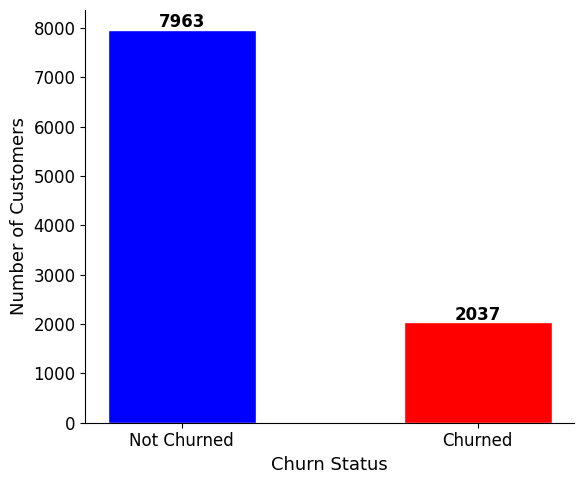

In [6]:
# Figure 1: Class Distribution
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(['Not Churned', 'Churned'],
              df['Exited'].value_counts().values,
              color=['Blue', 'Red'], edgecolor='white', width=0.5)

ax.set_ylabel('Number of Customers', fontsize=13)
ax.set_xlabel('Churn Status', fontsize=13)
ax.tick_params(labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, v in zip(bars, df['Exited'].value_counts().values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 50,
            str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/figure1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

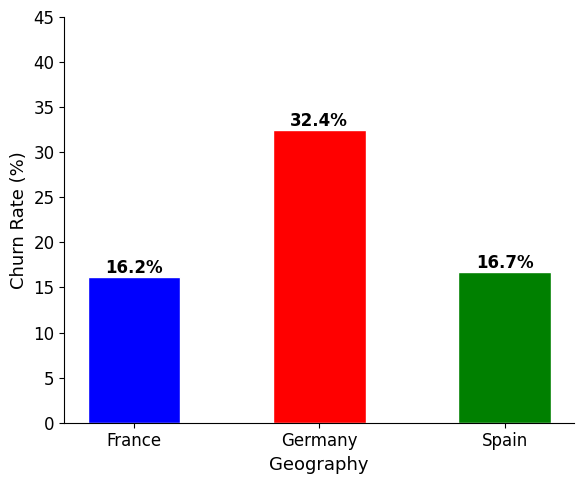

In [7]:
# Figure 2: Churn Rate by Geography
fig, ax = plt.subplots(figsize=(6, 5))

churn_by_geo = df.groupby('Geography')['Exited'].mean() * 100
bars = ax.bar(churn_by_geo.index, churn_by_geo.values,
              color=['Blue', 'Red', 'Green'], edgecolor='white', width=0.5)

ax.set_ylabel('Churn Rate (%)', fontsize=13)
ax.set_xlabel('Geography', fontsize=13)
ax.tick_params(labelsize=12)
ax.set_ylim(0, 45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, v in zip(bars, churn_by_geo.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/figure2_churn_by_geography.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Figure 3: Churn Rate by Number of Products
fig, ax = plt.subplots(figsize=(6, 5))

churn_by_products = df.groupby('NumOfProducts')['Exited'].mean() * 100
bars = ax.bar(churn_by_products.index.astype(str), churn_by_products.values,
              color=['#2196F3', '#4CAF50', '#F44336', '#F44336'],
              edgecolor='white', width=0.5)

ax.set_ylabel('Churn Rate (%)', fontsize=13)
ax.set_xlabel('Number of Products', fontsize=13)
ax.tick_params(labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, v in zip(bars, churn_by_products.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/figure3_churn_by_products.png', dpi=150, bbox_inches='tight')
plt.show()

## Key findings

- The dataset contains 10,000 customer records and the target variable is imbalanced, with substantially more non-churned than churned customers.
- Geography, age, and number of products show visible differences in churn rates, suggesting that these variables may contain useful predictive information.
- Identifier columns such as RowNumber, CustomerId, and Surname are not suitable for modelling and are removed during preprocessing.